# Tarea 2 - Jefersson Manzanares C34509

### Importación de paquetes necesarios

In [2]:
from skopt import gp_minimize
import numpy as np
from skopt.space import Real
import matplotlib.pyplot as plt

### Definición de las funciones necesarias

In [3]:
def pop_dyn_step(x, r, eps=0.05):
  if x==0:
    return 0
  x_next = x + r * x * (1 - x) + eps * np.random.normal()
  return max(x_next, 0)


def generate_prec_policy(x1, x2, y2):
  #
  def policy(obs):
    if obs <= x1:
      return 0
    if obs >= x2:
      return y2
    if x1 < obs < x2:
      return y2 * (obs - x1) / (x2 - x1)
  #
  return policy


def policy_func(x, model):
    #Separa los parametros del modelo
    x1, x2, y2 = model.x

    #Genera la policy func (utilizando notacion vectorial)
    return np.where(x <= x1, 0, np.where(x >= x2, y2, y2 * (x - x1) / (x2 - x1)))


def evaluate_policy(params):
  x1, x2, y2 = params
  policy = generate_prec_policy(x1, x2, y2)
  init_pop = 0.5 # start at half carrying capacity
  pop = init_pop
  #
  r = 0.3
  #
  total_harvest = 0
  #
  for t in range(100):
    fishing_mortality = policy(pop)
    harvest = fishing_mortality * pop
    pop = pop - harvest
    #
    pop = pop_dyn_step(pop, r=r)
    #
    total_harvest += harvest
  #
  return - total_harvest

## Parte A

Optimizar para diferentes valores de **k** utilizando **LCB**.

In [4]:
#Valores de kappa a utilizar
KAPPA_VALS = [1, 3, 5]

#Define la cantidad de valores de kappa
N = len(KAPPA_VALS)

#Define los valores de tiempo donde va a evaluar la funcion
X_VALS = np.linspace(-1,3,100)

#Lista donde se van a guardar los modelos para cada kappa
MODELS_DATA = [0] * N

In [5]:
#Genera los modelos de optimizacion con LCB para cada kappa
for i in range(N):
    MODELS_DATA[i] = gp_minimize(
        func = evaluate_policy,
        dimensions = [Real(0.0,2.0), Real(0.0,2.0), Real(0.0,1.0)],
        n_calls = 50,
        acq_func = "LCB",
        kappa = KAPPA_VALS[i],
        n_initial_points = 10
    )

## Parte B

Graficar $m = m(x)$ para cada modelo generado

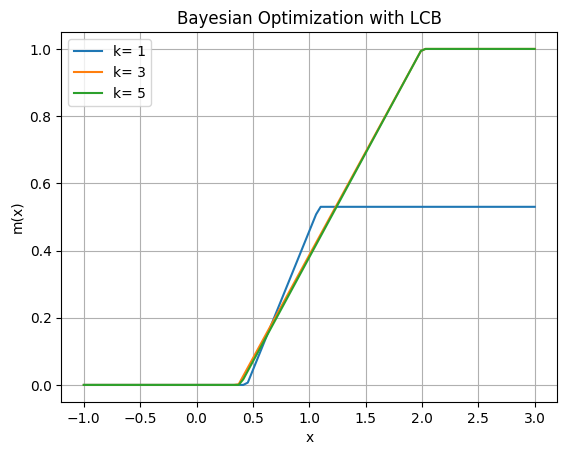

In [6]:
for i in range(N):
    #Genera un array de ceros para guardar los resultados
    m_vals = np.zeros(len(X_VALS))

    #Evalua la funcion policy con los valores del modelo
    m_vals = policy_func(X_VALS, MODELS_DATA[i]) 

    #Grafica la funcion policy
    plt.plot(X_VALS, m_vals, label=f"k= {KAPPA_VALS[i]}")

#Configura el plot
plt.title("Bayesian Optimization with LCB")
plt.ylabel("m(x)")
plt.xlabel("x")
plt.grid(True)
plt.legend()
plt.show()

## Parte C
Grafica una serie de tiempo para las funciones $x(t)$ y $m(t)$

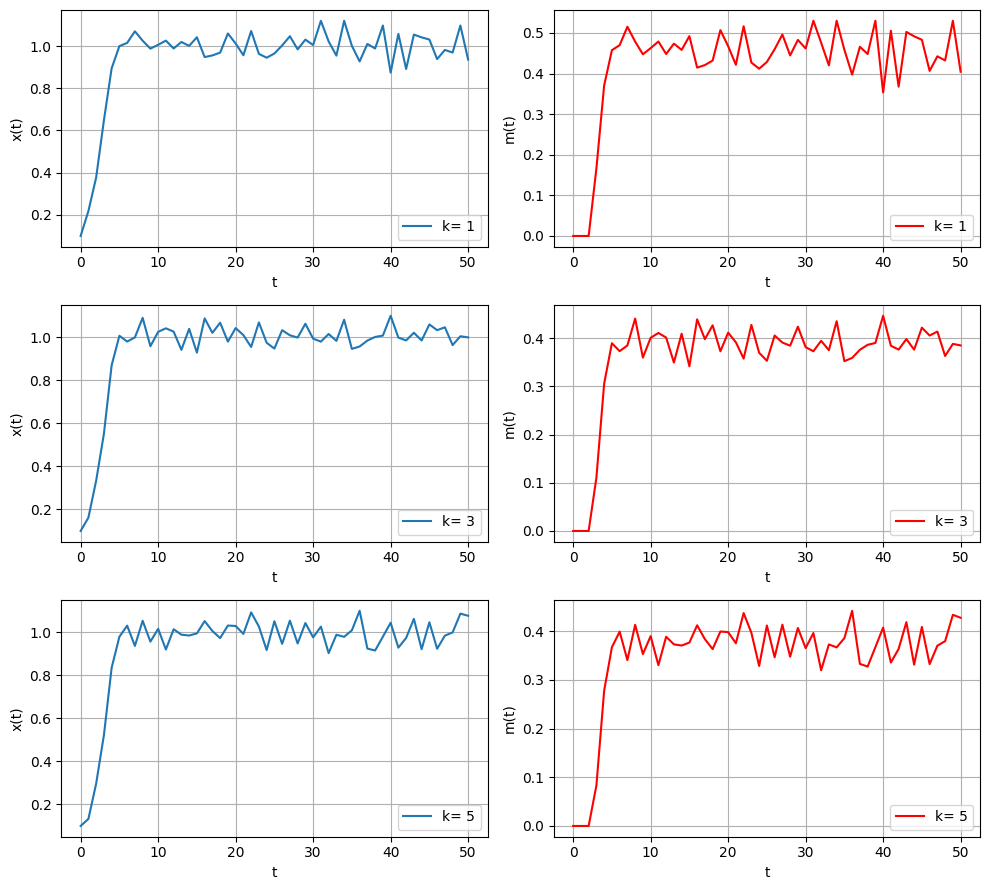

In [7]:
#Cantidad de paso temporales T+1
T = 50

fig, axs = plt.subplots(N, 2, figsize=(10, 3*N))

for i in range(N):
    #Lista para guardar el avance temporal de X(t) y m(t)
    x_vals = np.zeros(T+1)
    m_vals = np.zeros(T+1)
    
    #Posicion inicial
    x_vals[0] = 0.1

    #Tasa de reproduccion
    r = 1.2

    #Evalua la funcion x(t)
    for t in range(T):
        x_vals[t+1] = pop_dyn_step(x_vals[t], r)

    #Evalua la funcion m(x) con los valores de x calculados
    m_vals = policy_func(x_vals, MODELS_DATA[i]) 
    
    #Grafica x(t)
    axs[i, 0].plot(x_vals,label=f"k= {KAPPA_VALS[i]}")
    axs[i, 0].set_xlabel("t")
    axs[i, 0].set_ylabel("x(t)")
    axs[i, 0].grid(True)
    axs[i, 0].legend()

    #Grafica m(t)
    axs[i, 1].plot(m_vals,color="red",label=f"k= {KAPPA_VALS[i]}")
    axs[i, 1].set_xlabel("t")
    axs[i, 1].set_ylabel("m(t)")
    axs[i, 1].grid(True)
    axs[i, 1].legend()

plt.tight_layout()
plt.show() 

## Parte D
Repetir los pasos del A al C, pero esta vez utilizando **gp-hedge**

In [7]:
#Define la cantidad de modelos a generar
N = 3

#Define los valores de tiempo donde va a evaluar la funcion
X_VALS = np.linspace(-1,3,100)

#Lista donde se van a guardar los modelos para cada kappa
MODELS_DATA = [0] * N

In [8]:
#Genera los modelos de optimizacion con gp-hedge
for i in range(N):
    MODELS_DATA[i] = gp_minimize(
        func = evaluate_policy,
        dimensions = [Real(0.0,2.0), Real(0.0,2.0), Real(0.0,1.0)],
        n_calls = 100,
        n_initial_points = 10
    )

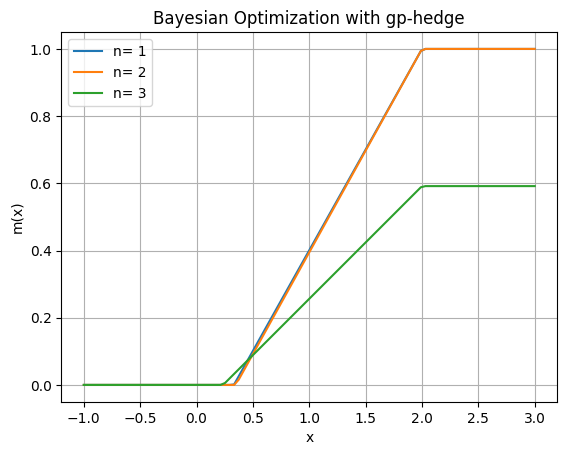

In [9]:
for i in range(N):
    #Genera un array de ceros para guardar los resultados
    m_vals = np.zeros(len(X_VALS))

    #Evalua la funcion policy con los valores del modelo
    m_vals = policy_func(X_VALS, MODELS_DATA[i]) 

    #Grafica la funcion policy
    plt.plot(X_VALS, m_vals, label=f"n= {i+1}")

#Configura el plot
plt.title("Bayesian Optimization with gp-hedge")
plt.ylabel("m(x)")
plt.xlabel("x")
plt.grid(True)
plt.legend()
plt.show()

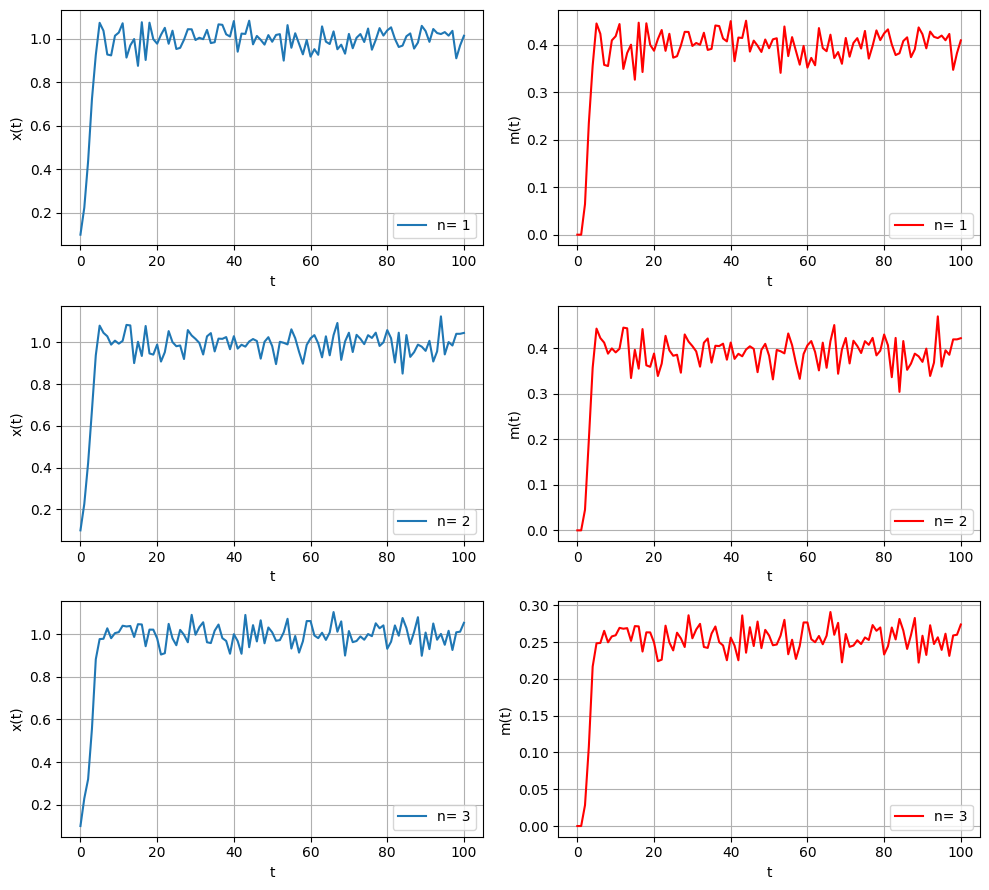

In [10]:
#Cantidad de paso temporales T+1
T = 100

fig, axs = plt.subplots(N, 2, figsize=(10, 3*N))

for i in range(N):
    #Lista para guardar el avance temporal de X(t) y m(t)
    x_vals = np.zeros(T+1)
    m_vals = np.zeros(T+1)
    
    #Posicion inicial
    x_vals[0] = 0.1

    #Tasa de reproduccion
    r = 1.2

    #Evalua la funcion x(t)
    for t in range(T):
        x_vals[t+1] = pop_dyn_step(x_vals[t], r)

    #Evalua la funcion m(x) con los valores de x calculados
    m_vals = policy_func(x_vals, MODELS_DATA[i]) 
    
    #Grafica x(t)
    axs[i, 0].plot(x_vals,label=f"n= {i+1}")
    axs[i, 0].set_xlabel("t")
    axs[i, 0].set_ylabel("x(t)")
    axs[i, 0].grid(True)
    axs[i, 0].legend()

    #Grafica m(t)
    axs[i, 1].plot(m_vals,color="red",label=f"n= {i+1}")
    axs[i, 1].set_xlabel("t")
    axs[i, 1].set_ylabel("m(t)")
    axs[i, 1].grid(True)
    axs[i, 1].legend()

plt.tight_layout()
plt.show() 